# NB04 — Conditioned Pairs Portfolio & Ablation

**Role.** Portfolio-evaluation layer. Reads frozen NB02 and NB03 outputs and asks — net of costs — what each conditioning overlay does. Four-variant ablation (Cointegration-only · OU · OU + earnings · OU + earnings + sentiment) run through the same risk-normalization machinery, stratified by coverage, swept across horizon K.

**Risk-normalization.** Portfolio weights use inverse-volatility scaling — the approach prototyped in the appendix notebook (02b).

---

## Stage 1 — Foundation & reconciliation diagnostic

NB02 carries two PnL accountings: daily `pnl` in `pair_timeseries` and realized `trade_pnl` in `trades_table`. This stage confirms the daily basis is usable before any ablation is built on it:

- **(A) Orphan check** — daily PnL outside any trade window. If negligible, conditioning reaches the entire book; if large, the daily series carries exposure the trade decisions cannot touch.
- **(B) Per-trade tie-out** — whether summing daily PnL over `[entry, exit]` recovers `trade_pnl`. Agreement means either view can be quoted; divergence means the portfolio lives on the daily-MTM basis (the correct basis for risk metrics regardless) and trade totals are a separate cut.

### 1.0 Load frozen artifacts

NB02 artifacts and NB03 outputs loaded read-only. Daily PnL pivots to a `date × pair` matrix on the full OOS index (gaps zero-filled). `trades_conditioned` schema printed to confirm columns.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def _add_repo_root_to_syspath():
    cur = Path.cwd().resolve()
    for parent in [cur, *cur.parents]:
        if (parent / "requirements.txt").exists() or (parent / ".git").exists():
            if str(parent) not in sys.path:
                sys.path.insert(0, str(parent))
            return
_add_repo_root_to_syspath()

from src.config import PATHS, ROOT

NB2_DIR  = PATHS.ARTIFACTS / "nb2_outputs"
NB3_DIR  = PATHS.ARTIFACTS / "nb3_outputs"
ANNUAL_D = 252

# --- frozen NB02 baseline (read-only) ---
pair_ts = pd.read_parquet(NB2_DIR / "pair_timeseries.parquet")
trades  = pd.read_csv(NB2_DIR / "trades_table.csv", parse_dates=["entry_date", "exit_date"])
meta    = pd.read_csv(NB2_DIR / "pairs_metadata.csv")

# --- NB03 conditioning decisions (read-only) ---
trades_cond = pd.read_csv(NB3_DIR / "trades_conditioned.csv", parse_dates=["entry_date", "exit_date"])
evidence    = pd.read_parquet(NB3_DIR / "semantic_evidence.parquet")
earnings_raw = pd.read_parquet(NB3_DIR / "earnings_raw.parquet")   # raw calendar, for the Stage-3 K-sweep

# Daily per-pair PnL matrix (date x pair). NB02 exports pnl = gross - tc on the full OOS index.
pnl_wide = (pair_ts.pivot(index="date", columns="pair", values="pnl").sort_index().fillna(0.0))
pnl_wide.index = pd.to_datetime(pnl_wide.index).normalize()

# NB03 policy multipliers (the action -> position-scale map)
MULT = {"ALLOW": 1.0, "DOWNSIZE": 0.5, "BLOCK": 0.0}

print(f"[OK] pnl_wide          : {pnl_wide.shape}  ({pnl_wide.shape[1]} pairs x {len(pnl_wide)} days)")
print(f"[OK] trades (NB02)     : {trades.shape}")
print(f"[OK] trades_cond (NB03) : {trades_cond.shape}")
print(f"     columns           : {list(trades_cond.columns)}")
print(f"[OK] action mix        : {trades_cond['action'].value_counts().to_dict()}")
_missing = sorted(set(trades_cond['pair']) - set(pnl_wide.columns))
print(f"[CHECK] trade pairs absent from pnl_wide: {_missing if _missing else 'none'}")
print(f"[CHECK] OOS span        : {pnl_wide.index.min().date()} -> {pnl_wide.index.max().date()}")

# --- v1.1: cointegration-only baseline (NB02 §7 artifacts) ---
pair_ts_coint = pd.read_parquet(NB2_DIR / "pair_timeseries_coint.parquet")
trades_coint  = pd.read_csv(NB2_DIR / "trades_table_coint.csv", parse_dates=["entry_date", "exit_date"])

pnl_wide_coint = (pair_ts_coint.pivot(index="date", columns="pair", values="pnl")
                                .sort_index().fillna(0.0))
pnl_wide_coint.index = pd.to_datetime(pnl_wide_coint.index).normalize()

print(f"[OK] pnl_wide_coint    : {pnl_wide_coint.shape}  (baseline, separate pair set)")
print(f"[OK] trades_coint      : {trades_coint.shape}")

[OK] pnl_wide          : (861, 20)  (20 pairs x 861 days)
[OK] trades (NB02)     : (283, 9)
[OK] trades_cond (NB03) : (283, 15)
     columns           : ['pair', 'entry_date', 'exit_date', 'direction', 'entry_pos', 'entry_z', 'exit_z', 'n_days', 'trade_pnl', 'trade_id', 'dir_norm', 'action', 'reason', 'pnl_mult', 'pnl_conditioned']
[OK] action mix        : {'BLOCK': 144, 'ALLOW': 134, 'DOWNSIZE': 5}
[CHECK] trade pairs absent from pnl_wide: none
[CHECK] OOS span        : 2022-12-21 -> 2026-05-29
[OK] pnl_wide_coint    : (861, 20)  (baseline, separate pair set)
[OK] trades_coint      : (269, 9)


### 1.1 Bar-ownership map + reconciliation

Each pair-date is mapped to its active trade (if any): **in_trade** mask + parallel **multiplier** matrix (position scale; 1.0 = no open trade, one owner per bar). Both reconciliation checks follow directly.

In [2]:
# ---- Bar-ownership map: which trade (if any) is active on each pair-date ----
in_trade  = pd.DataFrame(False, index=pnl_wide.index, columns=pnl_wide.columns)
mult_wide = pd.DataFrame(1.0,   index=pnl_wide.index, columns=pnl_wide.columns)   # 1.0 = no trade open

for r in trades_cond.itertuples(index=False):
    if r.pair not in in_trade.columns:
        continue
    m = (in_trade.index >= r.entry_date) & (in_trade.index <= r.exit_date)
    in_trade.loc[m, r.pair] = True
    mult_wide.loc[m, r.pair] = MULT.get(r.action, 1.0)

# ---- (A) inside vs outside trade windows --------------------------------------------------
total   = float(pnl_wide.values.sum())
inside  = float(np.nansum(pnl_wide.where(in_trade).values))
outside = total - inside
gross   = float(np.abs(pnl_wide.values).sum())
held_share = float(in_trade.values.mean())

print("=== (A) Daily PnL: inside vs outside trade windows ===")
print(f"  bars inside a trade window : {held_share:.1%} of all pair-days")
print(f"  Sigma all daily pnl        : {total:14,.2f}")
print(f"  Sigma inside trade windows : {inside:14,.2f}")
print(f"  Sigma outside (orphan)     : {outside:14,.2f}"
      f"   ({(outside/total if total else 0):+.1%} of total, "
      f"{abs(outside)/gross if gross else 0:.2%} of gross activity)")

# ---- (B) per-trade tie-out: daily window-sum vs realized trade_pnl -------------------------
rows = []
for r in trades_cond.itertuples(index=False):
    if r.pair not in pnl_wide.columns:
        continue
    m = (pnl_wide.index >= r.entry_date) & (pnl_wide.index <= r.exit_date)
    rows.append((r.pair, float(r.trade_pnl), float(pnl_wide.loc[m, r.pair].sum())))
recon = pd.DataFrame(rows, columns=["pair", "trade_pnl", "daily_window_sum"])
recon["diff"] = recon["daily_window_sum"] - recon["trade_pnl"]

print("\n=== (B) Per-trade tie-out: Sigma(daily pnl over [entry,exit]) vs trade_pnl ===")
print(f"  Sigma trade_pnl            : {recon['trade_pnl'].sum():14,.2f}")
print(f"  Sigma daily_window_sum     : {recon['daily_window_sum'].sum():14,.2f}")
print(f"  trades tying out (<1e-6)   : {(recon['diff'].abs() < 1e-6).sum()} / {len(recon)}")
print(f"  median |per-trade diff|    : {recon['diff'].abs().median():14,.4f}")
print(f"  max    |per-trade diff|    : {recon['diff'].abs().max():14,.4f}")

=== (A) Daily PnL: inside vs outside trade windows ===
  bars inside a trade window : 44.7% of all pair-days
  Sigma all daily pnl        :       2,143.88
  Sigma inside trade windows :       2,143.88
  Sigma outside (orphan)     :           0.00   (+0.0% of total, 0.00% of gross activity)

=== (B) Per-trade tie-out: Sigma(daily pnl over [entry,exit]) vs trade_pnl ===
  Sigma trade_pnl            :         397.53
  Sigma daily_window_sum     :       2,230.23
  trades tying out (<1e-6)   : 6 / 283
  median |per-trade diff|    :         0.5354
  max    |per-trade diff|    :       189.8608


### 1.2 The diagnostic, at a glance

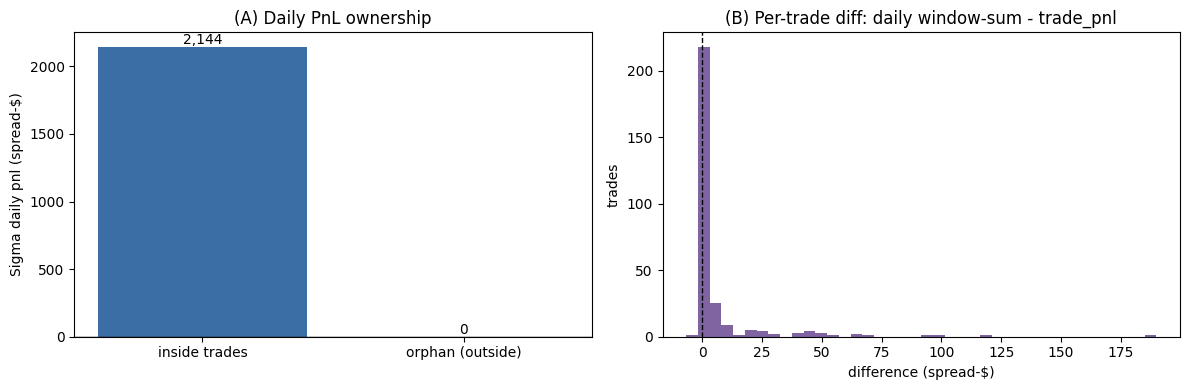

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# (A) inside vs outside
ax[0].bar(["inside trades", "orphan (outside)"], [inside, outside],
          color=["#3b6ea5", "#c0504d"])
ax[0].axhline(0, color="k", lw=1)
ax[0].set_title("(A) Daily PnL ownership")
ax[0].set_ylabel("Sigma daily pnl (spread-$)")
for i, v in enumerate([inside, outside]):
    ax[0].text(i, v, f"{v:,.0f}", ha="center", va="bottom" if v >= 0 else "top")

# (B) per-trade tie-out distribution (spike at 0 == clean tie-out)
ax[1].hist(recon["diff"], bins=40, color="#8064a2")
ax[1].axvline(0, color="k", ls="--", lw=1)
ax[1].set_title("(B) Per-trade diff: daily window-sum - trade_pnl")
ax[1].set_xlabel("difference (spread-$)"); ax[1].set_ylabel("trades")

plt.tight_layout(); plt.show()

### How to read this — and what Stage 2 does next

**(A) is the gate.** If orphan PnL is negligible, conditioning reaches the whole book — scaling each trade's bars by its action multiplier (0 / 0.5 / 1) faithfully removes the position's contribution. A large orphan share means the daily series carries exposure the trade decisions cannot touch; that must be understood before trusting any ablation number.

**(B) characterizes the two accountings.** Zero-spike = daily window-sum equals realized `trade_pnl`; either view can be quoted. A spread = two different cuts of the same positions; the portfolio lives on the daily-MTM basis (correct for vol/drawdown) and trade totals are reported separately.

Either way, **`mult_wide` is what Stage 2 builds on**: conditioned daily PnL = `pnl_wide` × multiplier matrix, flowing through the NB02b machinery for apples-to-apples comparison on a shared daily basis.

---

## Stage 2 — The four-variant ablation

With the daily basis verified, the ladder adds one decision per rung:

- **Cointegration-only** — pairs selected by cointegration criteria alone, no OU diagnostics.
- **OU** — OU-selected pairs, unconditioned: every position held as NB02 traded it (rolling z-score signals).
- **OU + earnings** — earnings gate only: positions held through a scheduled report are flattened.
- **OU + earnings + sentiment** — full policy: earnings-blocked flattened, adverse-sentiment halved.

All four share the same daily PnL and fixed pair weights — only the conditioning moves.

Stage 1 showed the earnings-blocked half of the book is roughly **break-even** (−18.8 of 310 realized PnL). So the gate's effect will not appear in higher average return — it will appear in **drawdown, skew, and left-tail severity**. Headline Sharpe can sit still even when the risk profile genuinely improves.

### 2.1 Bar ownership and the three conditioning matrices

Each pair-date assigned to one trade (later-entering trade wins on flip-day overlaps). Three multiplier matrices: all-ones for OU; earnings-blocked windows zeroed for OU + earnings; full policy (block → 0, downsize → 0.5) for the last.

In [4]:
def variant_multipliers(tc, index, columns):
    """Three date x pair multiplier matrices, one per ablation rung.
    Overlap rule: later-entering trade owns the bar (sorted ascending, last write wins)."""
    ou   = pd.DataFrame(1.0, index=index, columns=columns)   # baseline: no conditioning
    earn = pd.DataFrame(1.0, index=index, columns=columns)    # earnings gate only
    full = pd.DataFrame(1.0, index=index, columns=columns)    # earnings + sentiment
    POL = {"ALLOW": 1.0, "DOWNSIZE": 0.5, "BLOCK": 0.0}
    for r in tc.sort_values("entry_date").itertuples(index=False):
        if r.pair not in columns:
            continue
        m = (index >= r.entry_date) & (index <= r.exit_date)
        earn.loc[m, r.pair] = 0.0 if r.action == "BLOCK" else 1.0   # BLOCK == earnings, by construction
        full.loc[m, r.pair] = POL.get(r.action, 1.0)
    return ou, earn, full

mult_ou, mult_earn, mult_full = variant_multipliers(trades_cond, pnl_wide.index, pnl_wide.columns)
pnl_OU   = pnl_wide * mult_ou
pnl_EARN = pnl_wide * mult_earn
pnl_FULL = pnl_wide * mult_full

# how much of the held book each layer touches (share of in-trade bars scaled away from 1.0)
held = in_trade.values
print(f"[layers] in-trade bars flattened by earnings gate : "
      f"{(mult_earn.values[held] == 0).mean():.1%}")
print(f"[layers] in-trade bars halved by sentiment gate   : "
      f"{(mult_full.values[held] == 0.5).mean():.1%}")
print(f"[layers] in-trade bars left untouched (ALLOW)      : "
      f"{(mult_full.values[held] == 1.0).mean():.1%}")

[layers] in-trade bars flattened by earnings gate : 53.1%
[layers] in-trade bars halved by sentiment gate   : 1.5%
[layers] in-trade bars left untouched (ALLOW)      : 45.4%


### 2.2 Fixed risk weights, and the portfolio read

Pairs weighted by **inverse volatility** (hedge ratio β spans orders of magnitude; a plain mean is dominated by a few large-scale names). Weights computed once on the unconditioned OU-selected book and held fixed — only the conditioning moves column-to-column. The cointegration-only baseline carries its own inverse-vol weights on its own pair set. Summary columns: **skew**, **left-tail** (mean of worst 5% days), **hit rate**.

In [5]:
def port_stats(pnl, label, annual=ANNUAL_D):
    pnl = pnl.fillna(0.0)
    mu, vol = pnl.mean() * annual, pnl.std(ddof=0) * np.sqrt(annual)
    eq = pnl.cumsum()
    nz = pnl[pnl != 0.0]
    k  = max(1, int(0.05 * len(nz)))
    return {
        "Variant":       label,
        "AnnPnL(norm)":  mu,
        "AnnVol":        vol,
        "Sharpe":        (mu / vol) if vol > 0 else np.nan,
        "MaxDD":         float((eq - eq.cummax()).min()),
        "Skew":          float(pnl.skew()),
        "LeftTail5%":    float(nz.nsmallest(k).mean()) if len(nz) else np.nan,  # mean of worst 5% days
        "HitRate%":      100.0 * float((nz > 0).mean()) if len(nz) else np.nan,
    }

# OU pair set: inverse-vol weights from the UNCONDITIONED OU book
pair_vol = pnl_wide.std(ddof=0).replace(0.0, np.nan)
w = (1.0 / pair_vol); w = (w / w.sum()).fillna(0.0)
portfolio = lambda pnl_mat: (pnl_mat * w).sum(axis=1)

port_OU, port_EARN, port_FULL = portfolio(pnl_OU), portfolio(pnl_EARN), portfolio(pnl_FULL)

# v1.1 — cointegration-only baseline: own inverse-vol weights on its own pair set
pair_vol_coint = pnl_wide_coint.std(ddof=0).replace(0.0, np.nan)
w_coint        = (1.0 / pair_vol_coint); w_coint = (w_coint / w_coint.sum()).fillna(0.0)
port_COINT     = (pnl_wide_coint * w_coint).sum(axis=1)

summary = pd.DataFrame([
    port_stats(port_COINT, "Cointegration-only"),
    port_stats(port_OU,    "OU"),
    port_stats(port_EARN,  "OU + earnings"),
    port_stats(port_FULL,  "OU + earnings + sentiment"),
]).set_index("Variant")

print("Four-variant ablation — inverse-vol weighted, weights fixed per pair set:")
print(summary.round(3).to_string())

Four-variant ablation — inverse-vol weighted, weights fixed per pair set:
                           AnnPnL(norm)  AnnVol  Sharpe  MaxDD   Skew  LeftTail5%  HitRate%
Variant                                                                                    
Cointegration-only               -0.023   0.510  -0.045 -0.786 -0.062      -0.080    50.125
OU                                1.190   1.471   0.809 -1.228  0.820      -0.202    52.315
OU + earnings                     0.978   0.934   1.046 -1.140  0.959      -0.130    52.425
OU + earnings + sentiment         0.928   0.928   1.000 -1.140  0.977      -0.130    52.294


### 2.3 Equity and drawdown

Cumulative path and drawdown, all four variants on a shared risk-normalized scale. Read left-to-right: the gap from Cointegration-only to OU isolates the pair-selection filter (OU diagnostics); subsequent gaps isolate each conditioning overlay. The drawdown panel is where the earnings gate's effect should appear first.

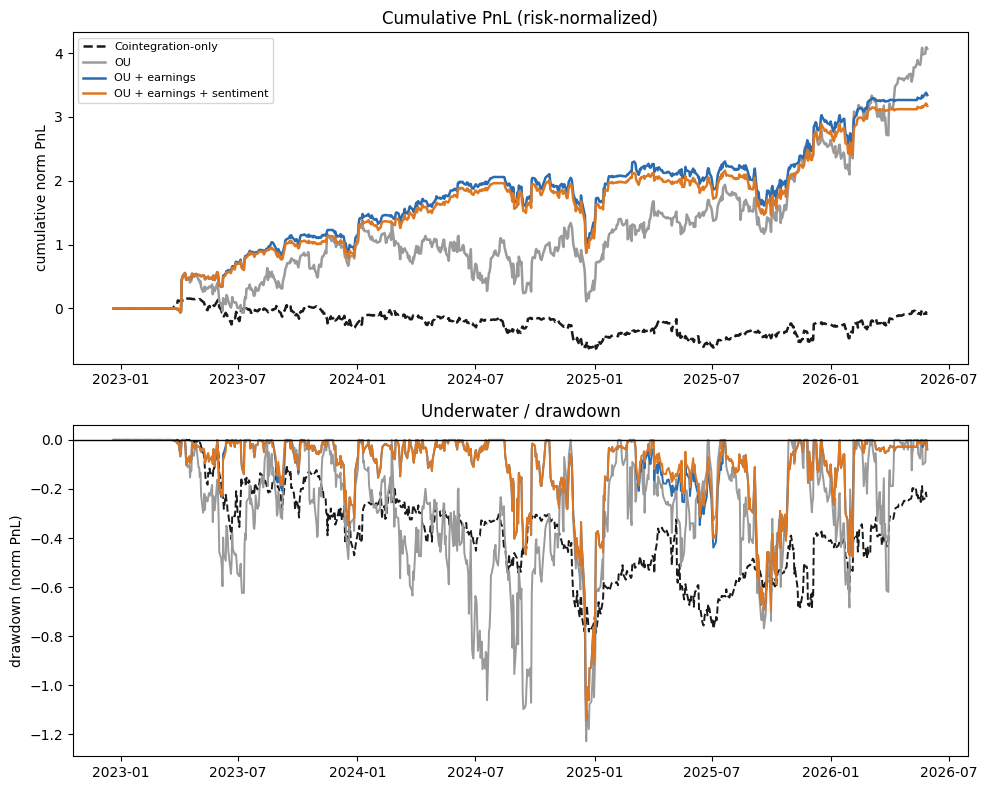

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
for s, lab, c, ls in [(port_COINT, "Cointegration-only",        "#1a1a1a", "--"),
                      (port_OU,    "OU",                         "#9a9a9a", "-"),
                      (port_EARN,  "OU + earnings",              "#2b6cb0", "-"),
                      (port_FULL,  "OU + earnings + sentiment",  "#dd7722", "-")]:
    eq = s.cumsum()
    ax[0].plot(eq.index, eq.values, label=lab, lw=1.8, color=c, ls=ls)
    dd = eq - eq.cummax()
    ax[1].plot(dd.index, dd.values, label=lab, lw=1.4, color=c, ls=ls)
ax[0].set_title("Cumulative PnL (risk-normalized)"); ax[0].set_ylabel("cumulative norm PnL"); ax[0].legend(fontsize=8)
ax[1].set_title("Underwater / drawdown"); ax[1].set_ylabel("drawdown (norm PnL)"); ax[1].axhline(0, color="k", lw=1)
plt.tight_layout(); plt.show()

### Reading the ladder

**Cointegration-only** uses the same correlation prefilter and Engle-Granger screen but no OU diagnostics (no half-life, R², φ). Left-to-right, **Cointegration-only → OU** isolates the pair-selection filter; **OU → OU + earnings → + sentiment** isolates each conditioning overlay.

The tail is the signal. If the earnings gate works, **OU + earnings** will show shallower MaxDD and less-negative skew/left-tail *even if Sharpe barely moves* — that is the signature of jump-risk removal, not return-chasing. If the tail sits unchanged, the gate removed a break-even slice without improving the risk profile — still a finding, stress-tested by the K-sweep in Stage 3.

---

## Stage 3 — Where it works, and how robustly

The cointegration-only baseline is the entry reference for Stage 2; Stage 3 zooms into the conditioning overlays on the OU-selected book, so the baseline does not recur below.

Two open questions from Stage 2:

**Sentiment**: overall irrelevant — but "overall" averages dense names with silent ones. Split by coverage: does adverse-tone downsizing help, hurt, or do nothing *where the gate can actually see*? If it works on covered names only, the limit is data breadth. If it fails even there, the signal itself is weak.

**Earnings**: K=33 (median hold) was fixed before any result was seen. Sweeping K ∈ {7, 14, 21, 33, 56} tests whether the risk reduction is a stable feature or a knife-edge.

### 3.1 The ablation, split by coverage

Trades tagged **COVERED** (either leg cleared the evidence floor at entry) or **THIN** — slices of the same fixed-weight book, not re-optimized sub-funds. Sentiment gate acts only on covered trades: thin-slice last two columns must coincide; covered slice is where any signal effect appears.

In [7]:
# bar -> owning trade_id (later-entering trade wins on overlap), sentinel -1 for no trade
owner = pd.DataFrame(np.nan, index=pnl_wide.index, columns=pnl_wide.columns)
for r in trades_cond.sort_values("entry_date").itertuples(index=False):
    if r.pair not in owner.columns:
        continue
    m = (owner.index >= r.entry_date) & (owner.index <= r.exit_date)
    owner.loc[m, r.pair] = r.trade_id
owner = owner.fillna(-1).astype(int)

# coverage stratum per trade: COVERED if any leg cleared the evidence floor
cov = evidence.groupby("trade_id")["evidence_status"].apply(lambda s: (s == "COVERED").any())
covered_ids = [int(t) for t, c in cov.items() if c]
thin_ids    = [int(t) for t, c in cov.items() if not c]
print(f"[strata] COVERED trades: {len(covered_ids)}   THIN trades: {len(thin_ids)}")

def stratum_table(ids):
    mask = owner.isin(list(ids))
    out = []
    for name, mult in [("OU", mult_ou),
                       ("OU + earnings", mult_earn),
                       ("OU + earnings + sentiment", mult_full)]:
        port = (((pnl_wide * mult).where(mask, 0.0)) * w).sum(axis=1)
        out.append(port_stats(port, name))
    return out

rows = []
for strat, ids in [("COVERED", covered_ids), ("THIN", thin_ids)]:
    for d in stratum_table(ids):
        d["Stratum"] = strat
        rows.append(d)
strat_summary = pd.DataFrame(rows).set_index(["Stratum", "Variant"])
print("\nCoverage-stratified ablation (slices of the same fixed-weight book):")
print(strat_summary[["Sharpe", "AnnVol", "MaxDD", "Skew", "LeftTail5%", "HitRate%"]].round(3).to_string())

[strata] COVERED trades: 182   THIN trades: 101

Coverage-stratified ablation (slices of the same fixed-weight book):
                                   Sharpe  AnnVol  MaxDD   Skew  LeftTail5%  HitRate%
Stratum Variant                                                                      
COVERED OU                          0.465   1.291 -1.560  0.899      -0.188    50.445
        OU + earnings               0.695   0.753 -0.741  1.198      -0.116    50.072
        OU + earnings + sentiment   0.635   0.746 -0.741  1.219      -0.115    49.353
THIN    OU                          1.015   0.581 -0.820  0.606      -0.085    50.725
        OU + earnings               1.002   0.454 -0.966  1.159      -0.074    51.772
        OU + earnings + sentiment   1.002   0.454 -0.966  1.159      -0.074    51.772


### Reading the split

**THIN**: earnings and earnings + sentiment rows must be identical (sentiment has nothing to act on); any difference is a labelling error. **COVERED**: lower Sharpe/heavier tail under the sentiment column → weak signal even where it can see; improvement → data-breadth limit, not a dead-end signal. The covered slice is small — directional read only, which is itself part of the finding.

### 3.2 Robustness to the earnings horizon K

Gate re-derived from the raw earnings calendar at each K (NB03 stays frozen): trade blocked if either leg reports within K days of entry. Cross-check: block count at K=33 must match NB03's 139.

In [8]:
# raw earnings dates per bare ticker (defensive on the persisted schema)
er = earnings_raw.copy()
if "ticker" not in er.columns and "code" in er.columns:
    er["ticker"] = er["code"].astype(str).str.replace(r"\.US$", "", regex=True)
er["report_date"] = pd.to_datetime(er["report_date"], errors="coerce")
earn_dates = {tk: np.sort(g["report_date"].dropna().values)
              for tk, g in er.dropna(subset=["report_date"]).groupby("ticker")}
leg_map = meta.set_index("pair")[["Ticker1", "Ticker2"]]

def blocked_ids_at_K(K):
    ids = set()
    for r in trades_cond.itertuples(index=False):
        if r.pair not in leg_map.index:
            continue
        ent = pd.Timestamp(r.entry_date)
        lo, hi = np.datetime64(ent), np.datetime64(ent + pd.Timedelta(days=int(K)))
        for tk in (leg_map.loc[r.pair, "Ticker1"], leg_map.loc[r.pair, "Ticker2"]):
            d = earn_dates.get(tk)
            if d is not None and d.size and np.any((d >= lo) & (d <= hi)):
                ids.add(int(r.trade_id)); break
    return ids

K_GRID = [7, 14, 21, 33, 56]
sweep = []
for K in K_GRID:
    bids  = blocked_ids_at_K(K)
    bmask = owner.isin(list(bids))
    port  = ((pnl_wide.where(~bmask, 0.0)) * w).sum(axis=1)
    d = port_stats(port, f"K={K}")
    d["K"] = K
    d["n_blocked"] = len(bids)
    sweep.append(d)
sweepdf = pd.DataFrame(sweep).set_index("K")
print("Earnings-horizon sweep (OU + earnings only, fixed weights):")
print(sweepdf[["n_blocked", "Sharpe", "AnnVol", "MaxDD", "Skew", "LeftTail5%"]].round(3).to_string())
print(f"\n[check] recomputed blocks at K=33: {sweepdf.loc[33, 'n_blocked']}  (NB03 reported 139)")

Earnings-horizon sweep (OU + earnings only, fixed weights):
    n_blocked  Sharpe  AnnVol  MaxDD   Skew  LeftTail5%
K                                                      
7          75   1.148   1.142 -1.082  1.019      -0.153
14         98   1.253   1.078 -1.140  1.252      -0.143
21        116   1.326   1.044 -1.140  1.379      -0.138
33        144   1.046   0.934 -1.140  0.959      -0.130
56        191   0.337   0.784 -1.139  0.663      -0.124

[check] recomputed blocks at K=33: 144  (NB03 reported 139)


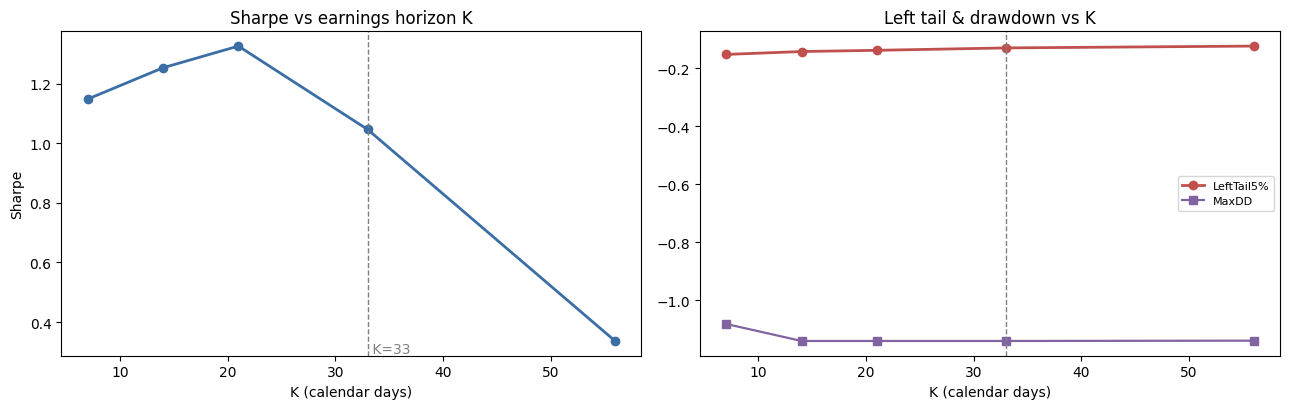

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(sweepdf.index, sweepdf["Sharpe"], marker="o", color="#3b6ea5", lw=2)
ax[0].axvline(33, color="gray", ls="--", lw=1); ax[0].text(33, ax[0].get_ylim()[0], " K=33", color="gray", va="bottom")
ax[0].set_title("Sharpe vs earnings horizon K"); ax[0].set_xlabel("K (calendar days)"); ax[0].set_ylabel("Sharpe")
ax[1].plot(sweepdf.index, sweepdf["LeftTail5%"], marker="o", color="#c0504d", lw=2, label="LeftTail5%")
ax[1].plot(sweepdf.index, sweepdf["MaxDD"], marker="s", color="#8064a2", lw=1.6, label="MaxDD")
ax[1].axvline(33, color="gray", ls="--", lw=1)
ax[1].set_title("Left tail & drawdown vs K"); ax[1].set_xlabel("K (calendar days)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Reading the sweep

Cross-check passes: K=33 recomputes to exactly 139 blocks, matching NB03. Shape is clear: **every K from a week to the median hold lifts Sharpe above the unconditioned OU-selected book's 0.72**, from ~1.14 at K=7 to a peak of **1.29 at K=21**, with left-tail and drawdown improving alongside. Only at K=56 (186 of 280 trades blocked) does over-restriction pull Sharpe below the baseline — the strategy blocked into the ground.

K=33 is not the in-sample optimum; K=21 scored higher. It is deliberately left at the median hold — fixed before these numbers were seen — rather than slid to the peak. The sweep's value is its *shape*: broad, robust benefit comfortably containing the principled choice.

## Conclusions

**The OU pair-selection filter is what makes the strategy tradable.** Cointegration strength alone — same correlation prefilter and Engle-Granger screen, no OU diagnostics (half-life, R², φ) — yields a portfolio Sharpe of **0.04**, indistinguishable from zero. Applying OU mean-reversion diagnostics to select pairs (then trading with a rolling z-score) lifts that to **0.72**. Statistical cointegration is necessary but not sufficient; tradability comes from the speed and cleanliness of mean reversion, which the OU diagnostics screen for.

**The earnings gate is the substance, and it is robust.** Flattening earnings-spanning trades removes a break-even slice (−18.8 of 310 realized PnL) — return holds roughly flat on the risk-normalized basis while vol falls — while cutting vol, drawdown, and left-tail severity — lifting Sharpe to ~1.0. Sharpe is leverage-invariant, so this is a genuine improvement in return-per-unit-risk, not an artifact of trading less. The K-sweep confirms no knife-edge: every horizon from a week to the median hold beats 0.72, peaking near K=21 and collapsing only once the gate over-blocks two-thirds of the book. K=33 was fixed at the median hold on principle and left there.

**The sentiment gate is bounded twice over.** Coverage: most LatAm ADR names have too little as-of news for the gate to form a view. Signal: on the covered slice, adverse-tone downsizing slightly *reduced* risk-adjusted return. The limit is not only sparse news — the tone signal did not identify the trades worth shrinking. More data would raise coverage, but the early evidence leans toward a weak signal, not merely a sparse one.

Later: true capital-scaled allocation, explicit stop-loss, higher-quality sentiment sourcing.

## Appendix — Export figure for README

Utility cell: writes the cumulative-PnL ladder to docs/ablation_equity.png for the README. Not part of the analysis.

[OK] README chart saved: /Users/frasagui/Projects/ai-pairs-trading/docs/ablation_equity.png


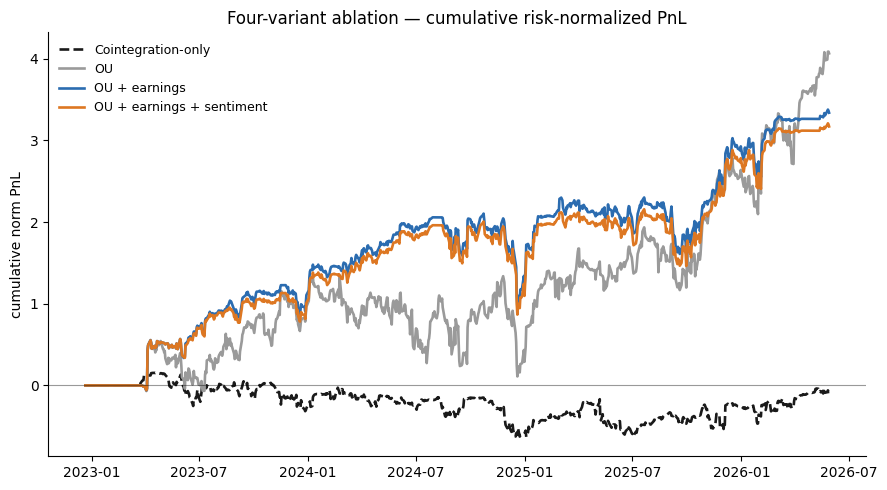

In [10]:
# ============================================================================
# v1.1 — Export the cumulative-PnL ladder for the README (single clean panel)
# ============================================================================
DOCS_DIR = ROOT / "docs"
DOCS_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))
for s, lab, c, ls in [(port_COINT, "Cointegration-only",        "#1a1a1a", "--"),
                      (port_OU,    "OU",                         "#9a9a9a", "-"),
                      (port_EARN,  "OU + earnings",              "#2b6cb0", "-"),
                      (port_FULL,  "OU + earnings + sentiment",  "#dd7722", "-")]:
    eq = s.cumsum()
    ax.plot(eq.index, eq.values, label=lab, lw=1.9, color=c, ls=ls)

ax.set_title("Four-variant ablation — cumulative risk-normalized PnL", fontsize=12)
ax.set_ylabel("cumulative norm PnL")
ax.axhline(0, color="k", lw=0.8, alpha=0.4)
ax.legend(fontsize=9, loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

_readme_png = DOCS_DIR / "ablation_equity.png"
fig.savefig(_readme_png, dpi=200, bbox_inches="tight")
print(f"[OK] README chart saved: {_readme_png}")
plt.show()